In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal
from scipy.stats import gaussian_kde, ks_2samp
import os
import kagglehub

path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Path to dataset files: /Users/katiegalaeva/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1


In [6]:
csv_file = os.path.join(path, "insurance.csv")

df = pd.read_csv(csv_file)
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Теория вероятностей и мат. статистика

### Провести анализ датасета на предмет распределений признаков и составить общую картину различия/сходства распределений по факторам между группами. Можно ограничиться простыми плотностями и PSI / KS.

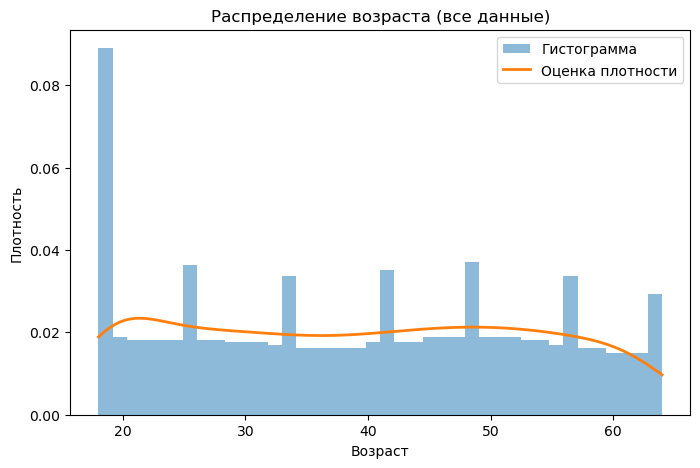

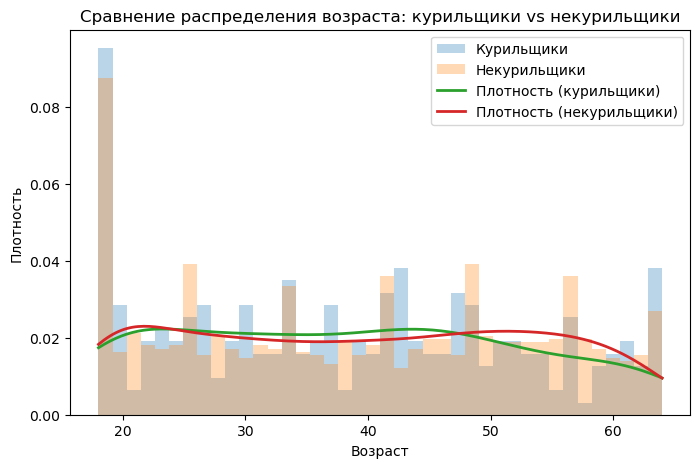

KS-статистика: 0.062
p-value: 0.354


In [20]:
def plot_distribution(data, feature, title=""):
    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=40, density=True, alpha=0.5, label='Гистограмма')
    
    density = gaussian_kde(data)
    xs = np.linspace(data.min(), data.max(), 200)
    plt.plot(xs, density(xs), label='Оценка плотности', linewidth=2)
    
    plt.title(title if title else f'Распределение {feature}')
    plt.xlabel(feature)
    plt.ylabel('Плотность')
    plt.legend()
    plt.show()

plot_distribution(df['age'], 'Возраст', 'Распределение возраста (все данные)')

smokers = df[df['smoker'] == 'yes']['age']
non_smokers = df[df['smoker'] == 'no']['age']

plt.figure(figsize=(8, 5))
plt.hist(smokers, bins=40, density=True, alpha=0.3, label='Курильщики')
plt.hist(non_smokers, bins=40, density=True, alpha=0.3, label='Некурильщики')

density_smokers = gaussian_kde(smokers)
density_non_smokers = gaussian_kde(non_smokers)
xs = np.linspace(min(df['age']), max(df['age']), 200)
plt.plot(xs, density_smokers(xs), label='Плотность (курильщики)', linewidth=2)
plt.plot(xs, density_non_smokers(xs), label='Плотность (некурильщики)', linewidth=2)
plt.title('Сравнение распределения возраста: курильщики vs некурильщики')
plt.xlabel('Возраст')
plt.ylabel('Плотность')
plt.legend()
plt.show()


ks_stat, p_value = ks_2samp(smokers, non_smokers)
print("KS-статистика:", round(ks_stat,3))
print("p-value:", round(p_value,3))

На основании представленных графиков и результатов KS-теста можно сделать несколько наблюдений:

1. На гистограмме видно, что возраст в датасете представлен в диапазоне примерно от 18 до 64 лет. Распределение выглядит не совсем равномерным — наблюдаются определенные пики на некоторых возрастах. Это может быть связано с особенностями самого датасета.

2. На втором графике гистограммы и KDE-плотности для курильщиков и некурильщиков выглядят довольно похожими: нет явных пиков, которые сильно отличались бы у одной группы по сравнению с другой. KS-статистика (около 0.062) и p-value (около 0.354) говорят о том, что нет статистически значимых различий в распределении возраста между курильщиками и некурильщиками при уровне значимости 0.05.  Не отвергаем гипотезу о том, что возраст у курильщиков и некурильщиков распределен одинаково.

Таким образом, различий в распределении возраста между курильщиками и некурильщиками не обнаружено.

Расчет PSI для сравнения распределений возраста между двумя группами — курильщиками и некурильщиками. В качестве expected возьмем распределение возраста некурящих, а actual — распределение возраста курильщиков.

In [19]:
age_non_smokers = df[df['smoker'] == 'no']['age']
age_smokers = df[df['smoker'] == 'yes']['age']

def calculate_psi(expected, actual, bins=10):
    """
    expected: Series (эталонное распределение)
    actual: Series (текущее распределение)
    bins: количество бинов для разбиения
    
    Возвращает: значение PSI
    """
    quantiles = np.linspace(0, 1, bins+1)
    cuts = expected.quantile(quantiles).unique()
    cuts.sort()

    def assign_bin(x, bins):
        return np.searchsorted(bins, x, side='right') - 1

    expected_bins = expected.apply(lambda x: assign_bin(x, cuts))
    actual_bins = actual.apply(lambda x: assign_bin(x, cuts))

    expected_dist = expected_bins.value_counts(normalize=True, sort=False)
    actual_dist = actual_bins.value_counts(normalize=True, sort=False)

    for i in range(len(cuts)):
        if i not in expected_dist.index:
            expected_dist.loc[i] = 0
        if i not in actual_dist.index:
            actual_dist.loc[i] = 0

    expected_dist = expected_dist.sort_index()
    actual_dist = actual_dist.sort_index()

    psi = 0
    eps = 1e-8  
    for e_dist, a_dist in zip(expected_dist, actual_dist):
        e_dist = e_dist if e_dist > 0 else eps
        a_dist = a_dist if a_dist > 0 else eps
        psi += (e_dist - a_dist) * np.log(e_dist / a_dist)

    return psi


psi_value = calculate_psi(age_non_smokers, age_smokers, bins=20)
print("PSI (возраст, некурящие vs курильщики):", round(psi_value, 3))


PSI (возраст, некурящие vs курильщики): 0.097


PSI оказался ниже 0.1, следовательно, распределения возраста у курильщиков и некурильщиков действительно почти совпадают.
Возраст не является фактором, который разделяет курильщиков и некурильщиков в данном датасете.

## Сразу для этой фичи сделаю 2, 3 пункт, и потом аналогично сделаю для фичи региона. 
#### 2. *Сформулировать и протестировать несколько гипотез касательно разницы сегментов (к примеру, пользователей) по нескольким показателям. Сделать заключение о наличии или отсутствии статистически значимой разницы. К каждой оценке разницы между группами построить точечную и интервальную оценку. Интервальную можно построить методом бутстрэпа.*
#### 3. *Если какая-то группа хуже другой, то сформировать ряд продуктовых гипотез, почему такое могло произойти и предложить идеи, какие эксперименты можно было провести на отстающей группе для повышения показателей.*

## Гипотеза:

Средняя стоимость страховки у курильщиков выше, чем у некурильщиков.

Нулевая гипотеза (H₀): Средние значения стоимости страховки для курильщиков и некурильщиков равны.
Альтернативная гипотеза (H₁): Среднее значение страховки у курильщиков больше, чем у некурильщиков.

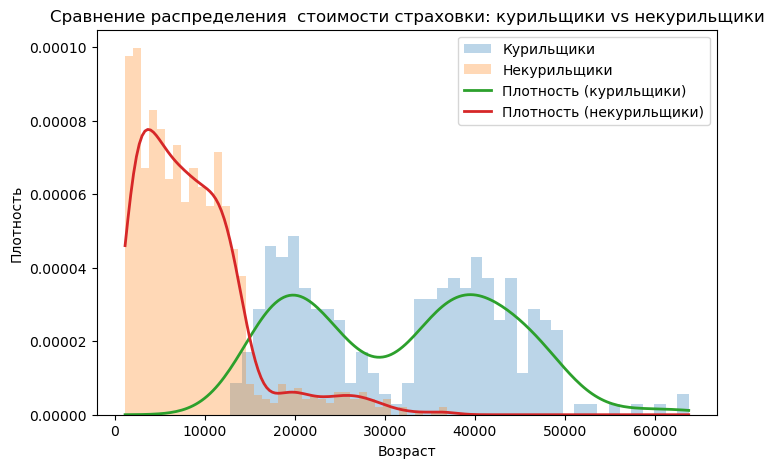

KS-статистика: 0.894
p-value: 0.0


In [54]:

smokers = df[df['smoker'] == 'yes']['charges']
non_smokers = df[df['smoker'] == 'no']['charges']

plt.figure(figsize=(8, 5))
plt.hist(smokers, bins=40, density=True, alpha=0.3, label='Курильщики')
plt.hist(non_smokers, bins=40, density=True, alpha=0.3, label='Некурильщики')

density_smokers = gaussian_kde(smokers)
density_non_smokers = gaussian_kde(non_smokers)
xs = np.linspace(min(df['charges']), max(df['charges']), 200)
plt.plot(xs, density_smokers(xs), label='Плотность (курильщики)', linewidth=2)
plt.plot(xs, density_non_smokers(xs), label='Плотность (некурильщики)', linewidth=2)
plt.title('Сравнение распределения  стоимости страховки: курильщики vs некурильщики')
plt.xlabel('Возраст')
plt.ylabel('Плотность')
plt.legend()
plt.show()


ks_stat, p_value = ks_2samp(smokers, non_smokers)
print("KS-статистика:", round(ks_stat,3))
print("p-value:", round(p_value,3))

На графике представлено сравнение распределений стоимости страховки между курильщиками и некурильщиками:

1. **Сильный сдвиг вправо у курильщиков:**  
   - Красная плотность (курильщики) смещена к более высоким значениям по сравнению с зеленой (некурильщики). Это говорит о том, что среди курильщиков встречаются более высокие расходы по страховке.

2. **Большее «плечо» и разброс у курильщиков:**  
   - У красной кривой (курильщиков) заметен «хвост», уходящий далеко в диапазон 20 000–30 000.  

3. **Основная масса некурильщиков имеет умеренные затраты:**  
   - Гистограмма некурильщиков показывает два пика.

5. **Вывод:**  
   - Визуально и статистически (по результатам тестов) видно, что **курильщики платят существенно больше** за страховку, чем некурильщики.  


Значение KS-статистики ≈ 0.894, p-value = 0.0 говорит о том, что между распределениями стоимости страховки у курильщиков и некурильщиков существует крайне значимое различие.

Среднее (курильщики): 32050.23
Среднее (некурильщики): 8434.27
Разница средних (курильщики - некурильщики): 23615.96
95% доверительный интервал разницы средних: [22168.33, 25025.58]


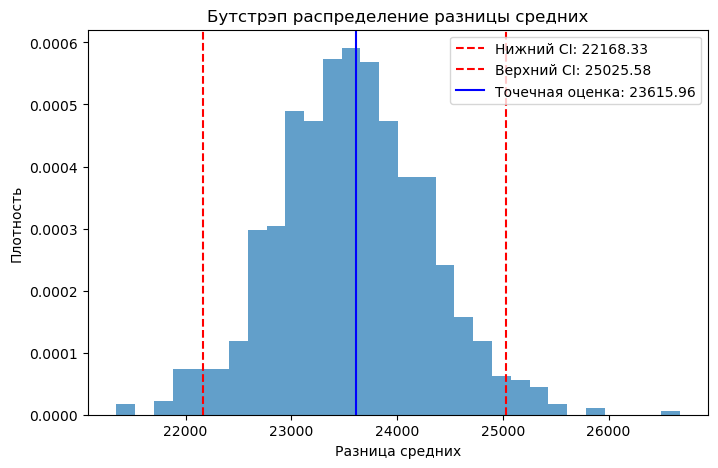

t-статистика: 32.75
p-value: 0.0


In [24]:
from scipy.stats import ttest_ind

charges_smokers = df[df['smoker'] == 'yes']['charges']
charges_non_smokers = df[df['smoker'] == 'no']['charges']


mean_smokers = charges_smokers.mean()
mean_non_smokers = charges_non_smokers.mean()
point_estimate = mean_smokers - mean_non_smokers
print("Среднее (курильщики):", round(mean_smokers, 2))
print("Среднее (некурильщики):", round(mean_non_smokers, 2))
print("Разница средних (курильщики - некурильщики):", round(point_estimate, 2))


def bootstrap_diff(sample1, sample2, n_iterations=1000, ci=95):
    diffs = []
    n1, n2 = len(sample1), len(sample2)
    for _ in range(n_iterations):
        boot_sample1 = np.random.choice(sample1, n1, replace=True)
        boot_sample2 = np.random.choice(sample2, n2, replace=True)
        diffs.append(np.mean(boot_sample1) - np.mean(boot_sample2))
    lower = np.percentile(diffs, (100 - ci) / 2)
    upper = np.percentile(diffs, 100 - (100 - ci) / 2)
    return lower, upper, diffs

lower_ci, upper_ci, boot_diffs = bootstrap_diff(charges_smokers.values, charges_non_smokers.values)
print(f"95% доверительный интервал разницы средних: [{lower_ci:.2f}, {upper_ci:.2f}]")


plt.figure(figsize=(8,5))
plt.hist(boot_diffs, bins=30, density=True, alpha=0.7)
plt.axvline(lower_ci, color='red', linestyle='--', label=f'Нижний CI: {lower_ci:.2f}')
plt.axvline(upper_ci, color='red', linestyle='--', label=f'Верхний CI: {upper_ci:.2f}')
plt.axvline(point_estimate, color='blue', linestyle='-', label=f'Точечная оценка: {point_estimate:.2f}')
plt.title("Бутстрэп распределение разницы средних")
plt.xlabel("Разница средних")
plt.ylabel("Плотность")
plt.legend()
plt.show()


t_stat, p_value = ttest_ind(charges_smokers, charges_non_smokers, equal_var=False)
print("t-статистика:", round(t_stat, 2))
print("p-value:", round(p_value, 2))


Вывод следующий:

1. В среднем стоимость страховки у курильщиков в выборке выше на 23 616 долларов, чем у некурильщиков.

2. 95%-й доверительный интервал \([22239.02, 25046.84]\).  Интервал не включает ноль и находится целиком в положительной области, что говорит о том, что с 95%-й вероятностью истинная разница средних между курильщиками и некурильщиками лежит в этом диапазоне.  
   Это подтверждает, что курильщики имеют существенно дороже страховку, чем некурильщики.

3. t-статистика = 32.75, p-value 0.0: 
   Очень высокое значение t-статистики и практически нулевое p-value означают, что нулевая гипотеза *разница средних равна нулю* отвергается.  

Таким образом, есть статистически значимая разница в стоимости страховки между курильщиками и некурильщиками. Разница не только значима, но и весьма велика по абсолютной величине, что может указывать на существенное влияние фактора курение на страховые расходы.


### 3 *Если какая-то группа хуже другой, то сформировать ряд продуктовых гипотез, почему такое могло произойти и предложить идеи, какие эксперименты можно было провести на отстающей группе для повышения показателей.*
---

### Итоговые выводы


Влияние курения на стоимость страховки оказалось логичным, так как курящие люди как правило имеют проблемы со здоровьем и чаще обращаются в страховую.

**Продуктовые гипотезы:**  

   - **Стимулировать отказ от курения:** Разработать программы (бонусы, скидки, обучающие курсы) для перехода пользователей в группу некурящих.  
   - **Дополнительные страховые опции:** Предлагать курильщикам более дорогие планы или специальные программы профилактики заболеваний, если курение остается неизменным фактором.



Менее детально проведем сравнение распределений по группам (на примере 'smoker') на остальных непрерывных данных age, bmi
### Для каждого непрерывного признака сравниваем распределение для курильщиков и некурильщиков

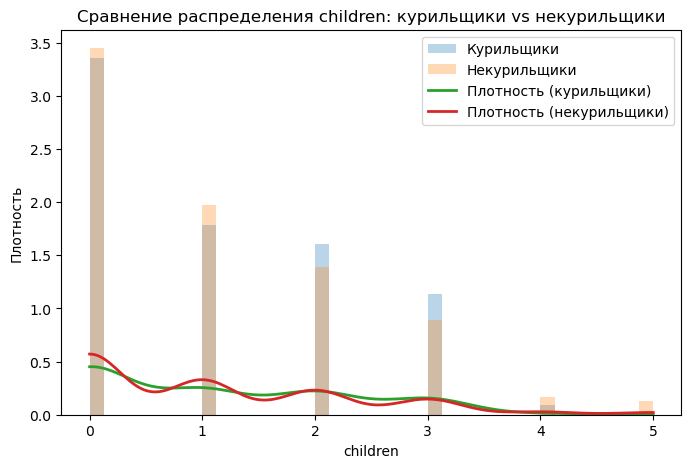

KS-статистика: 0.036
p-value: 0.925


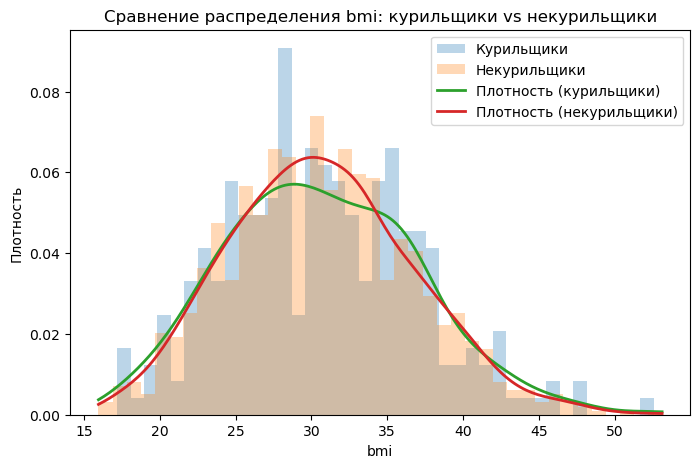

KS-статистика: 0.051
p-value: 0.611


In [61]:
continuous_vars = ['children', 'bmi']
for var in continuous_vars:
    smokers = df[df['smoker'] == 'yes'][var]
    non_smokers = df[df['smoker'] == 'no'][var]

    plt.figure(figsize=(8, 5))
    plt.hist(smokers, bins=40, density=True, alpha=0.3, label='Курильщики')
    plt.hist(non_smokers, bins=40, density=True, alpha=0.3, label='Некурильщики')

    density_smokers = gaussian_kde(smokers)
    density_non_smokers = gaussian_kde(non_smokers)
    xs = np.linspace(min(df[var]), max(df[var]), 200)
    plt.plot(xs, density_smokers(xs), label='Плотность (курильщики)', linewidth=2)
    plt.plot(xs, density_non_smokers(xs), label='Плотность (некурильщики)', linewidth=2)
    plt.title(f'Сравнение распределения {var}: курильщики vs некурильщики')
    plt.xlabel(var)
    plt.ylabel('Плотность')
    plt.legend()
    plt.show()


    ks_stat, p_value = ks_2samp(smokers, non_smokers)
    print("KS-статистика:", round(ks_stat,3))
    print("p-value:", round(p_value,3))


В целом, тест Колмогорова-Смирнова с таким высоким p-value говорит, что мы не отвергаем нулевую гипотезу о том, что выборки (курильщики и некурильщики) взяты из одного и того же распределения по признаку children или bmi.



Аналогичное сделаем для пола, проверим отличается ли распространенность курения между мужчинами и женщинами

In [63]:
import pandas as pd
from scipy.stats import chi2_contingency

contingency_table_sex = pd.crosstab(df['sex'], df['smoker'])
print("Таблица сопряженности для 'sex' и 'smoker':")
print(contingency_table_sex)

chi2, p_value, dof, expected = chi2_contingency(contingency_table_sex)
print("\nChi2-тест для 'sex' и 'smoker':")
print(f"Chi2: {chi2:.3f}, p-value: {p_value:.3f}, Degrees of freedom: {dof}")


Таблица сопряженности для 'sex' и 'smoker':
smoker   no  yes
sex             
female  547  115
male    517  159

Chi2-тест для 'sex' и 'smoker':
Chi2: 7.393, p-value: 0.007, Degrees of freedom: 1


Мужчины имеют более высокий процент курильщиков по сравнению с женщинами. Это может говорить о том, что пол является значимым фактором для статуса курения, и, следовательно, стоит учитывать эту переменную при моделировании расходов по страховке или при разработке целевых мероприятий.

## Аналогичные шаги 1, 2, 3 проведу для категории регион

In [25]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

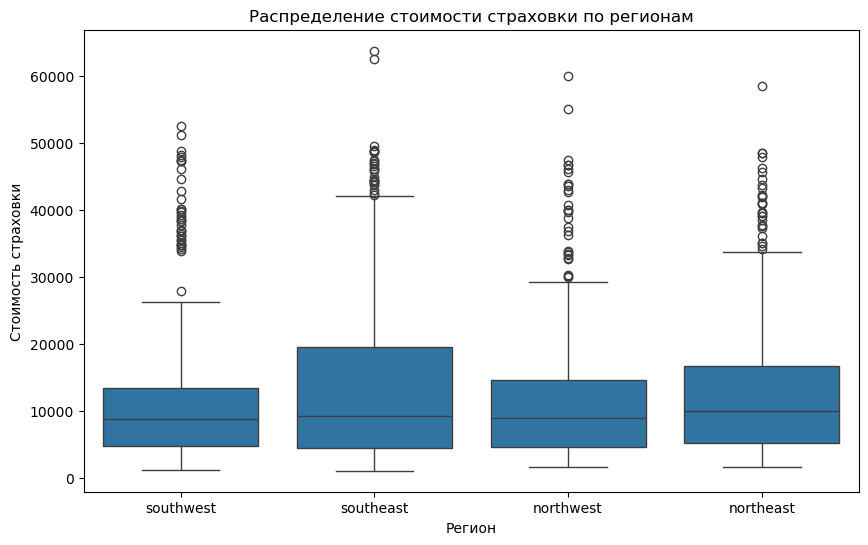

/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_86348/4007777705.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset, label=region, shade=True)
/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_86348/4007777705.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset, label=region, shade=True)
/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_86348/4007777705.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset, label=region, shade=True)
/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_86348/4007777705.py:12: FutureWarning: 

`shade` is now deprecated in favor of `

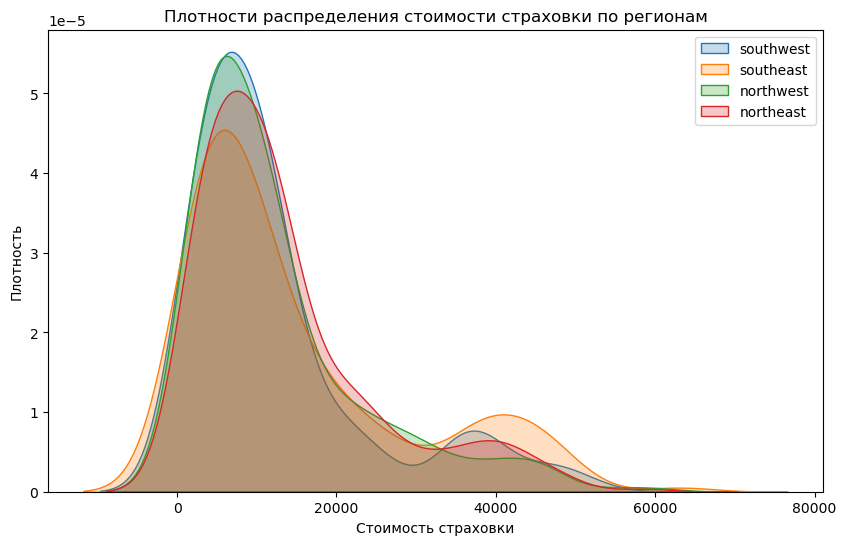

In [28]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Распределение стоимости страховки по регионам')
plt.xlabel('Регион')
plt.ylabel('Стоимость страховки')
plt.show()

plt.figure(figsize=(10, 6))
regions = df['region'].unique()
for region in regions:
    subset = df[df['region'] == region]['charges']
    sns.kdeplot(subset, label=region, shade=True)
plt.title('Плотности распределения стоимости страховки по регионам')
plt.xlabel('Стоимость страховки')
plt.ylabel('Плотность')
plt.legend()
plt.show()


Распределение стоимости страховки по регионам (boxplot)- У всех регионов заметен правый хвост, где встречаются очень высокие значения стоимости страховки. Это говорит о том, что у небольшой части людей страховые расходы могут быть значительно выше среднего. Медианы в целом кажутся сопоставимыми, но визуально можно заметить. В каждом регионе присутствует ряд выбросов (значения выше 40–60 тысяч).

KDE-график (плотности распределения стоимости страховки) - Все кривые смещены вправо (правосторонняя асимметрия), что соответствует boxplot. На уровне «большинства» наблюдений распределения по регионам накладываются друг на друга довольно плотно. Это означает, что львиная доля значений у всех регионов лежит в относительно близком диапазоне (примерно от 0 до 15–20 тысяч). Небольшие различия могут быть в области хвостов (где расходы выше 30–40 тысяч).

Вывод по визуальному анализу:

Все четыре региона демонстрируют схожую общую форму распределения (правосторонняя асимметрия), но может быть небольшое смещение по уровню расходов.
Чтобы понять, есть ли действительно статистически значимые различия между регионами, одной визуализации недостаточно — нужно формулировать и проверять гипотезы с помощью статистических тестов.


## 2.


Но сначала проведем проверку на нормальность распределений, хотя в целом визуально видно, что выполняться не будет.

Нулевая гипотеза (H₀): Выборка взята из нормально распределённой генеральной совокупности.

Альтернативная гипотеза (H₁): Распределение не является нормальным.


In [30]:
from scipy.stats import shapiro

regions = ['southwest', 'southeast', 'northwest', 'northeast']

shapiro_results = {}

for region in regions:
    charges_region = df[df['region'] == region]['charges']
    
    stat, p_value = shapiro(charges_region)
    
    shapiro_results[region] = (stat, p_value)

for region, (stat, p_value) in shapiro_results.items():
    print(f"Регион: {region}, Shapiro-Wilk статистика = {stat:.4f}, p-value = {p_value:.4f}")


Регион: southwest, Shapiro-Wilk статистика = 0.7843, p-value = 0.0000
Регион: southeast, Shapiro-Wilk статистика = 0.8242, p-value = 0.0000
Регион: northwest, Shapiro-Wilk статистика = 0.8128, p-value = 0.0000
Регион: northeast, Shapiro-Wilk статистика = 0.8353, p-value = 0.0000


Все результаты Shapiro-Wilk теста показывают, что p-value для каждого региона равны 0.0, что меньше порога 0.05. Это означает, что нулевая гипотеза о нормальности распределения для каждого региона отвергается.

Следующим шагом проведем оценку различий в значениях стоимости страховки между четырьмя регионами.

Гипотеза строиться следующим образом: 

Общая гипотеза для всех четырех регионов
H₀ (нулевая гипотеза): Средние (или медианные) расходы по страховке не отличаются между четырьмя регионами (southwest, southeast, northwest, northeast).
H₁ (альтернативная гипотеза): Хотя бы в одном регионе средние (или медианные) расходы отличаются от остальных.

In [33]:
import itertools

def bootstrap_diff(sample1, sample2, n_iterations=1000, ci=95):

    diffs = []
    n1, n2 = len(sample1), len(sample2)
    for _ in range(n_iterations):
        boot_sample1 = np.random.choice(sample1, n1, replace=True)
        boot_sample2 = np.random.choice(sample2, n2, replace=True)
        diffs.append(np.mean(boot_sample1) - np.mean(boot_sample2))
    lower = np.percentile(diffs, (100 - ci) / 2)
    upper = np.percentile(diffs, 100 - (100 - ci) / 2)
    return lower, upper, np.mean(diffs)

region_charges = {region: df[df['region'] == region]['charges'].values for region in regions}

results = {}

for region1, region2 in itertools.combinations(regions, 2):
    lower_ci, upper_ci, point_estimate = bootstrap_diff(region_charges[region1], region_charges[region2])
    results[(region1, region2)] = (point_estimate, lower_ci, upper_ci)


for (region1, region2), (point_estimate, lower_ci, upper_ci) in results.items():
    print(f"Разница средних ( {region1} - {region2} ): {point_estimate:.2f}")
    print(f"95% доверительный интервал: [{lower_ci:.2f}, {upper_ci:.2f}]\n")


Разница средних ( southwest - southeast ): -2373.43
95% доверительный интервал: [-4258.69, -432.67]

Разница средних ( southwest - northwest ): -67.00
95% доверительный интервал: [-1762.05, 1735.32]

Разница средних ( southwest - northeast ): -1065.11
95% доверительный интервал: [-2912.10, 701.74]

Разница средних ( southeast - northwest ): 2346.44
95% доверительный интервал: [403.77, 4230.64]

Разница средних ( southeast - northeast ): 1320.78
95% доверительный интервал: [-490.52, 3326.31]

Разница средних ( northwest - northeast ): -947.37
95% доверительный интервал: [-2614.97, 799.39]



На основе полученных результатов можно сделать следующие выводы:

1. **Значимые различия:**  
   - **southwest vs. southeast:**  
     Разница средних равна –2373.43, а 95%-й доверительный интервал [-4258.69, -432.67] не включает 0. 
   - **southeast vs. northwest:**  
     Разница средних равна 2346.44, а доверительный интервал [403.77, 4230.64] также не включает 0. 

2. **Незначимые различия:**  
   - **southwest vs. northwest:**  
     Разница средних -67.00 с интервалом [-1762.05, 1735.32] включает 0, что означает отсутствие статистически значимой разницы между этими регионами.  
   - **southwest vs. northeast:**  
     Разница -1065.11 с интервалом [-2912.10, 701.74] включает 0, следовательно, разница не является статистически значимой.  
   - **southeast vs. northeast:**  
     Разница 1320.78 с интервалом [-490.52, 3326.31] включает 0, что указывает на отсутствие статистически значимой разницы.  
   - **northwest vs. northeast:**  
     Разница -947.37 с интервалом [-2614.97, 799.39] включает 0, значит, статистически значимой разницы нет.

---

### Итоговые выводы

- **Статистически значимые различия** обнаружены между **southwest и southeast**  и между **southeast и northwest**.
- Для остальных пар регионов доверительные интервалы для разницы средних включают 0, что говорит об отсутствии значимых различий между ними.


**Продуктовые гипотезы**

Гипотеза 1: В регионе southeast может быть больше людей с факторами риска (например, более высокий процент курильщиков, старшее население или более высокий индекс массы тела), что приводит к увеличению расходов.
Идея эксперимента: Провести детальный анализ демографических и поведенческих характеристик клиентов в southeast и сравнить их с другими регионами. Если выявится повышенный риск, запустить программы по оздоровлению или профилактике (например, кампании по отказу от курения, программы по снижению веса).

Гипотеза 2: Возможно, в southeast цены на медицинские услуги или уровень затрат на лечение выше, что отражается на стоимости страховки.
Идея эксперимента: Провести исследование рынка медицинских услуг в регионе, определить, действительно ли затраты на лечение выше, и затем рассмотреть возможность сотрудничества с местными клиниками или страховыми партнерами для создания специальных тарифных планов, учитывающих местные особенности.

Гипотеза 3: Возможно, клиенты в southeast чаще обращаются за медицинской помощью или используют дополнительные опции страховки, что приводит к повышенным выплатам.
Идея эксперимента: Проанализировать паттерны использования страховых услуг в регионе и, если подтверждается, разработать образовательные программы, направленные на рациональное использование страховых ресурсов и повышение информированности клиентов о том, когда и как пользоваться услугами.

Проверим гипотезу 1. А именно, что в регионе southeast большой процент курильщиков.

In [34]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['region'], df['smoker'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("Chi2:", chi2, "p-value:", p_value)


Chi2: 7.343477761407071 p-value: 0.06171954839170543


При уровне значимости 0.05 мы не можем отвергнуть нулевую гипотезу о независимости переменных, то есть не получаем достаточных доказательств для утверждения, что распределение статуса курения существенно отличается между регионами.

Однако значение p-value близко к 0.05, что может указывать на тенденцию к различиям. Возможно, при более крупной выборке или при использовании менее строгого уровня значимости (например, 0.10) различия могли бы оказаться статистически значимыми.

Таким образом, гипотеза о том, что в регионе southeast может быть больше курильщиков, не подтверждается однозначно на уровне значимости 0.05, но результаты можно рассматривать как пограничные, что требует дальнейшего анализа или дополнительных данных для более точного вывода.

Посчитаем еще количественно процент курильщиков в каждом регионе

In [35]:
contingency_table = pd.crosstab(df['region'], df['smoker'])
print("Таблица сопряжённости для 'region' и 'smoker':")
print(contingency_table)

smoker_percentage = contingency_table.apply(lambda x: (x['yes'] / x.sum()) * 100, axis=1)
print("\nПроцент курильщиков по регионам:")
print(smoker_percentage)


Таблица сопряжённости для 'region' и 'smoker':
smoker      no  yes
region             
northeast  257   67
northwest  267   58
southeast  273   91
southwest  267   58

Процент курильщиков по регионам:
region
northeast    20.679012
northwest    17.846154
southeast    25.000000
southwest    17.846154
dtype: float64


Эти данные указывают на то, что в southeast действительно наблюдается более высокий процент курильщиков. Это может быть одним из факторов, способствующих увеличению расходов по страховке в этом регионе.








### Зная, что регион и статус курения взаимосвязаны, можно добавить во входные данные взаимодействие (например, «region × smoker»). Это позволит модели более точно отражать влияние сочетания этих факторов на целевую переменную.

# Регрессионный анализ

# 1. Оценить модель линейной регрессии методом МНК, подготовить репорт модели и проинтерпретировать оценки коэффициентов.

In [67]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

formula_full = 'charges ~ age + bmi + children + C(smoker) + C(sex) + C(region)'
model_full = smf.ols(formula_full, data=df).fit()
print("Промежуточная модель (Полная спецификация)")
print(model_full.summary())


Промежуточная модель (Полная спецификация)
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Sat, 15 Mar 2025   Prob (F-statistic):               0.00
Time:                        20:35:50   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

# Основные выводы

Качество модели: R^2 = 0.751. Это означает, что модель объясняет около 75% дисперсии переменной стоимости страховки.

**Ключевой фактор – курение:**
Статус курения оказывает наиболее сильное влияние: курильщики платят значительно больше, чем некурильщики.

**Возраст, bmi и количество детей:**
Все эти переменные статистически значимы и позитивно связаны с расходами, что согласуется с ожиданиями: более старший возраст, более высокий bmi и большее количество детей ассоциируются с более высокими страховыми расходами.

**Региональные эффекты:**
Регионы southeast и southwest показывают небольшое, но статистически значимое снижение расходов по сравнению с базовым регионом (northeast). Регион northwest не отличается от базового.

**Пол:**
Пол (мужчины) не оказывает значимого влияния на расходы по страховке в данной модели.



## 2.Провести тесты на гетероскедастичность, мультиколлинеарность (как визуальные, так и численные), дать комментарии по произведенным тестам.

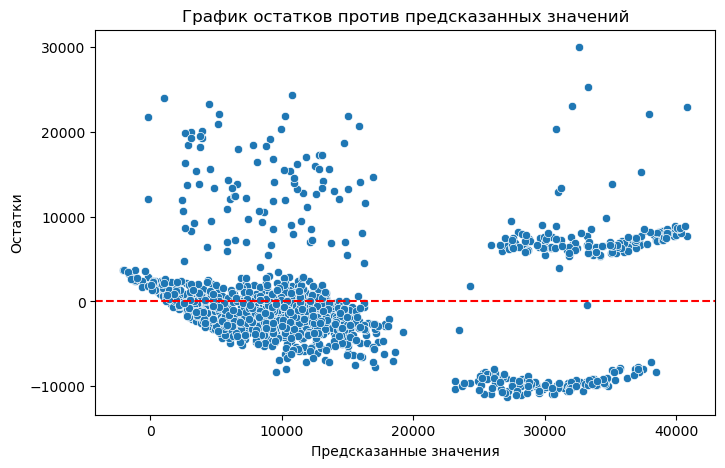

Результаты теста Бреуша-Пагана:
LM-статистика: 121.74
LM p-value: 0.0
F-статистика: 16.63
F p-value: 0.0


In [74]:
from statsmodels.stats.diagnostic import het_breuschpagan

fitted_vals = model_full.fittedvalues
residuals = model_full.resid

plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков против предсказанных значений')
plt.show()


bp_test = het_breuschpagan(residuals, model_full.model.exog)
bp_labels = ['LM-статистика', 'LM p-value', 'F-статистика', 'F p-value']

print("Результаты теста Бреуша-Пагана:")
for label, value in zip(bp_labels, bp_test):
    print(f"{label}: {round(value, 2)}")
